In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [24]:
df = pd.read_csv("BTC-USD.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [25]:
df['Target'] = df['Close'].shift(-1)

df.dropna(inplace=True)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Target
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,424.440002
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,394.795990
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,408.903992
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,398.821014
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,402.152008


In [26]:
X = df[['Open','High','Low','Close','Volume']]

y = df['Target']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [28]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [29]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [30]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [31]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE":[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,R2 Score
0,Linear Regression,1124.976542,0.989464
1,Decision Tree,22541.273998,-1.803900
2,Random Forest,22407.371717,-1.792334


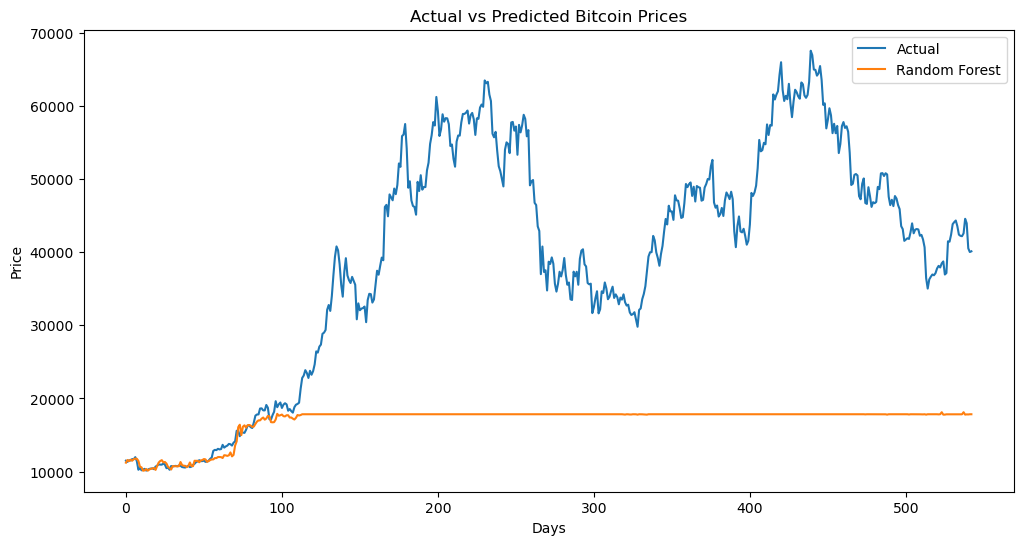

In [32]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")

plt.plot(rf_pred, label="Random Forest")

plt.title("Actual vs Predicted Bitcoin Prices")

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.show()

In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
3,Close,0.751605
2,Low,0.092409
0,Open,0.083946
1,High,0.070982
4,Volume,0.001058


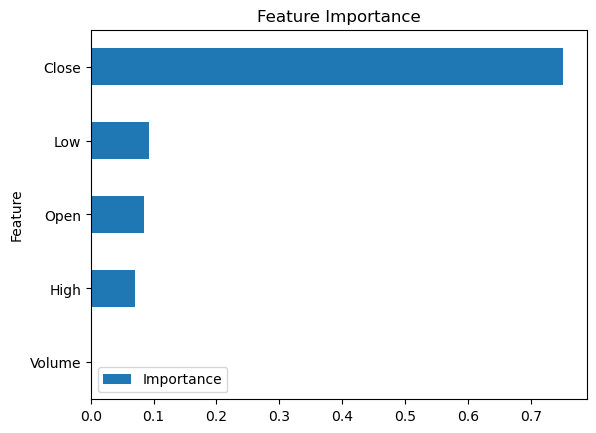

In [34]:
importance.sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Feature Importance")

plt.show()